# E09 - anisotropy removal as common-mode rejection (CMR)

Executes the pre-registered **E09** batch (E09-H49..H53) from
`docs/experiments/wmd-structure-distance-experiments.md`. The thesis: on the **diffuse**
cross-summary pairs (independent summaries of one IBM article - cosines bunched, transport
plan `T` spread) anisotropy removal is recast as a **differential amplifier** - pool both
documents' statements, reject the shared common mode (frequency anisotropy plus shared
topic), amplify what distinguishes them. The tension is selectivity: rejecting the shared
*topic* inflates the semantic distance. So every hypothesis is scored on **two axes** -
structural gain (sharper `T`, wider margin / dynamic range) against semantic cost
(SMD-fidelity, tier ordering) - and the headline **CMRR = structural differential gain /
semantic common-content loss**; a lever ships only at CMRR > 1.

- **Regime** - the diffuse cross-summary pairs from `data/processed/structure-fixture/pairs.json`,
  never the byte-identical reorder pool where E08-H47 was already sharp and inconclusive
- **Reuse** - E08 `posaug_cost` / `posaug_smd`, `tau_footrule` / `naive_footrule`,
  `all_but_the_top` (both-document top-k pooled PCA rejection), `cost_matrix` / `smd` /
  `transport_plan` from `src/docdistance/distance.py`
- **Output** - `reports/E09-anisotropy-cmr-metrics.json`, figures `reports/figures/E09/`,
  log `logs/E09-anisotropy-cmr.log`


## GPU selection

mmBERT statement embedding runs on the RTX 5000 Ada (GPU 2) selected by UUID - the same
device E07/E08 used. The optimal-transport solves are CPU numpy. The GPU cell is first and
runs before `torch` is imported anywhere.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu
os.environ["TOKENIZERS_PARALLELISM"]="false"; os.environ["TRANSFORMERS_VERBOSITY"]="error"; os.environ["HF_HUB_DISABLE_PROGRESS_BARS"]="1"
import warnings; warnings.filterwarnings("ignore")
import torch
print("torch",torch.__version__,"| cuda:",torch.cuda.is_available(),"|",torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.11.0+cu130 | cuda: True | NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import json, re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table
from loguru import logger

import ot
from docdistance.distance import (
    transport_plan, cost_matrix, smd, closeness, all_but_the_top,
)
from docdistance.encoders import load_encoder

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
print("imports ready | POT", ot.__version__)

imports ready | POT 0.9.6.post1


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
print(f"SEED={SEED}")

SEED=0


## Configuration

Loads the E07/E08 structure fixture, embeds every document once with **raw** mmBERT
(no anisotropy - the production single-pair regime CMR is meant to retrofit), and fixes the
diffuse regime, the tier-contrast guard, and the scoring constants. The diffuse regime is the
55 cross-summary pairs (every independent summary against every other); the semantic guard is
the 10 tier-contrast pairs (6 content-same gold pairs + 4 content-different adversarial pairs,
all anchored to `gold`).

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
FIX = ROOT / "data/processed/structure-fixture"
DOCSTORE = json.load(open(FIX / "statements.json"))
PAIRS = json.load(open(FIX / "pairs.json"))
if isinstance(PAIRS.get("cross_summary"), dict):  # per-article dict -> flat list (E07-E10 predate the grouping)
    PAIRS["cross_summary"] = [p for v in PAIRS["cross_summary"].values() for p in v]
META = json.load(open(FIX / "meta.json"))

DIFFUSE = [tuple(p) for p in PAIRS["cross_summary"]]   # 55 independent-summary pairs, diffuse T
TIER = PAIRS["tier_contrast"]                          # 10 gold-anchored pairs (6 same, 4 diff)

LAM_HEAD = 0.25            # E08-H44 headline positional weight for the structure distance
DEPTHS = [0, 1, 2, 3]     # E09-H51 rejection-depth sweep (D=0 == raw)
EPS_CMRR = 0.02           # floor on semantic loss so CMRR stays finite (preserved ranking -> CMRR is a lower bound)
BOOT_REPS = 60            # E09-H51 bootstrap reps for removed-direction stability
MARGIN_FLOOR = 0.0        # naive-margin reference (tau must beat greedy-1NN)

REPORT = ROOT / "reports/E09-anisotropy-cmr-metrics.json"
LOGFILE = ROOT / "logs/E09-anisotropy-cmr.log"
logger.remove(); logger.add(str(LOGFILE), level="INFO", mode="w")
logger.info("E09 anisotropy-CMR batch start | diffuse={} pairs, tier={} pairs", len(DIFFUSE), len(TIER))

# embed each document once - raw embeddings, no anisotropy (production single-pair regime)
ENC = load_encoder("torch", offline=False, device="cuda")
EMB = {label: ENC.encode(DOCSTORE[label]["statements"]) for label in DOCSTORE}
DEVICE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

RESULTS, VERDICTS = {}, {}
COL = {"raw": "#6c757d", "perpair": "#1f77b4", "offline": "#d62728",
       "gain": "#2ca02c", "cost": "#e8743b", "cmrr": "#9467bd", "chance": "#222222"}

t = Table(title="E09 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Device", DEVICE)
t.add_row("Fixture", f"{len(DOCSTORE)} docs, dim {next(iter(EMB.values())).shape[1]}")
t.add_row("Diffuse regime", f"{len(DIFFUSE)} cross-summary pairs (independent summaries, T diffuse)")
t.add_row("Semantic guard", f"{len(TIER)} tier-contrast pairs ("
                            f"{sum(p['content']=='same' for p in TIER)} same / "
                            f"{sum(p['content']=='diff' for p in TIER)} diff, gold-anchored)")
t.add_row("CMR mechanism", "both-document pooled top-k PCA rejection (all_but_the_top on {A,B})")
t.add_row("Structure dist", f"position-augmented Wasserstein, lambda={LAM_HEAD}")
t.add_row("CMRR", "structural differential gain / semantic common-content loss; ships at > 1")
t.add_row("Depths (H51)", str(DEPTHS))
console.print(t)
print("embedded", len(EMB), "docs | diffuse", len(DIFFUSE), "| tier", len(TIER))

                                       E09 configuration                                       
  Device            NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition                    
  Fixture           25 docs, dim 768                                                           
  Diffuse regime    58 cross-summary pairs (independent summaries, T diffuse)                  
  Semantic guard    10 tier-contrast pairs (6 same / 4 diff, gold-anchored)                    
  CMR mechanism     both-document pooled top-k PCA rejection (all_but_the_top on {A,B})        
  Structure dist    position-augmented Wasserstein, lambda=0.25                                
  CMRR              structural differential gain / semantic common-content loss; ships at > 1  
  Depths (H51)      [0, 1, 2, 3]

embedded 25 docs | diffuse 58 | tier 10


## Core machinery - CMR variants, both-axis scoring, the CMRR

Three building blocks, reused by every hypothesis.

- **CMR variants** - `raw` (identity), `perpair(k)` (pool A,B, reject top-k via
  `all_but_the_top`, re-L2-normalize - both-document common-mode rejection), and `offline(k)`
  (a top-k direction fit once on the 62-statement source-article background, applied per pair -
  the selectivity contrast for E09-H50)
- **Structural axis** - median `T` row-entropy (lower = sharper), the position-augmented
  Wasserstein dynamic range (std across diffuse pairs), and the naive margin
  `tau_footrule - naive_footrule` (does soft transport beat hard greedy-1NN)
- **Semantic axis** - SMD-fidelity = Spearman of SMD-with-CMR vs SMD-raw across the diffuse
  pairs (primary guard: is the content ranking preserved), and the tier-ordering violation
  count on the gold/adversarial guard
- **CMRR** - `g_struct / max(l_sem, EPS)` with `g_struct` the relative `T`-entropy reduction
  and `l_sem = 1 - SMD-fidelity`; the entropy reduction is the headline structural gain, the
  margin and dynamic-range gains are reported alongside

In [5]:
# --- reused E08 reads (verbatim carry-over) ---
def pos_vec(n):
    return np.arange(n) / max(n - 1, 1)

def posaug_cost(EA, EB, lam):
    d_sem = cost_matrix(EA, EB)
    pa, pb = pos_vec(len(EA)), pos_vec(len(EB))
    d_pos = np.abs(pa[:, None] - pb[None, :])
    return np.sqrt((1 - lam) * d_sem ** 2 + lam * d_pos ** 2)

def posaug_smd(EA, EB, lam):
    a, b = np.full(len(EA), 1 / len(EA)), np.full(len(EB), 1 / len(EB))
    return float(ot.emd2(a, b, posaug_cost(EA, EB, lam)))

def norm_footrule_ranks(order):
    n = len(order)
    return 0.0 if n < 2 else float(np.abs(np.asarray(order) - np.arange(n)).sum()) / (n * n // 2)

def induced_tau(T):
    posB = np.arange(T.shape[1])
    return (T @ posB) / (T.sum(1) + 1e-12)

def tau_footrule(EA, EB):
    order = np.argsort(np.argsort(induced_tau(transport_plan(EA, EB))))
    return norm_footrule_ranks(order)

def naive_footrule(EA, EB):
    order = np.argsort(np.argsort(cost_matrix(EA, EB).argmin(1)))
    return norm_footrule_ranks(order)

def row_entropy(T):
    P = T / (T.sum(1, keepdims=True) + 1e-12)
    H = -(P * np.log(P + 1e-12)).sum(1)
    return float(np.mean(H / np.log(T.shape[1])))

# --- offline-frozen direction (E08 cell-12 helpers, carried over) ---
def fit_direction(bg, k=1):
    mu = bg.mean(0); centered = bg - mu
    _, _, Vt = np.linalg.svd(centered, full_matrices=False)
    return mu, Vt[:k]

def apply_direction(E, mu, comps):
    centered = E - mu
    fixed = centered - centered @ comps.T @ comps
    return (fixed / (np.linalg.norm(fixed, axis=1, keepdims=True) + 1e-9)).astype(np.float32)

# --- CMR variant factories: each returns f(EA, EB) -> (EA', EB') ---
def raw_cmr(EA, EB):
    return EA, EB

def perpair_cmr(k):
    def f(EA, EB):
        out = all_but_the_top({"A": EA, "B": EB}, k=k)   # pool A,B, reject pooled top-k, re-L2-normalize
        return out["A"], out["B"]
    return f

def offline_cmr(k, bg_label="source"):
    mu, comps = fit_direction(EMB[bg_label], k=k)         # fit once on the frozen background
    def f(EA, EB):
        return apply_direction(EA, mu, comps), apply_direction(EB, mu, comps)
    return f

# --- both-axis scoring of a CMR transform over the diffuse pairs + tier guard ---
def score_axes(transform, embmap=None, pairs=None, tier=None, lam=LAM_HEAD):
    embmap = EMB if embmap is None else embmap
    pairs = DIFFUSE if pairs is None else pairs
    tier = TIER if tier is None else tier
    H, SMD, STRUCT, MARGIN = [], [], [], []
    for a, b in pairs:
        EA, EB = transform(embmap[a], embmap[b])
        H.append(row_entropy(transport_plan(EA, EB)))
        SMD.append(smd(EA, EB))
        STRUCT.append(posaug_smd(EA, EB, lam))
        MARGIN.append(tau_footrule(EA, EB) - naive_footrule(EA, EB))
    same = [smd(*transform(embmap[p["a"]], embmap[p["b"]])) for p in tier if p["content"] == "same"]
    diff = [smd(*transform(embmap[p["a"]], embmap[p["b"]])) for p in tier if p["content"] == "diff"]
    viol = int(sum(1 for s in same for d in diff if s >= d))
    same, diff = np.array(same), np.array(diff)
    dprime = float((diff.mean() - same.mean()) / np.sqrt(0.5 * (same.var() + diff.var()) + 1e-12))
    return {"H": np.array(H), "SMD": np.array(SMD), "STRUCT": np.array(STRUCT),
            "MARGIN": np.array(MARGIN), "entropy_med": float(np.median(H)),
            "struct_dr": float(np.std(STRUCT)), "naive_margin": float(np.mean(MARGIN)),
            "tier_viol": viol, "tier_pairs": len(same) * len(diff),
            "tier_dprime": dprime, "tier_same_mean": float(same.mean()), "tier_diff_mean": float(diff.mean())}

# --- CMRR: structural differential gain over semantic common-content loss ---
def cmrr(raw_s, var_s):
    g_struct = (raw_s["entropy_med"] - var_s["entropy_med"]) / max(raw_s["entropy_med"], 1e-9)
    g_dr = (var_s["struct_dr"] - raw_s["struct_dr"]) / max(raw_s["struct_dr"], 1e-9)
    g_margin = var_s["naive_margin"] - raw_s["naive_margin"]
    fidelity = float(spearmanr(raw_s["SMD"], var_s["SMD"]).correlation)
    l_sem = 1.0 - fidelity
    ratio = g_struct / max(l_sem, EPS_CMRR)
    return {"g_struct_entropy": g_struct, "g_struct_dr": g_dr, "g_margin": g_margin,
            "smd_fidelity": fidelity, "l_sem": l_sem, "cmrr": ratio,
            "l_sem_floored": l_sem < EPS_CMRR}

# --- E09-H51 bootstrap stability of the removed top-D pooled direction ---
def direction_stability(EA, EB, k, reps=BOOT_REPS, seed=0):
    P = np.concatenate([EA, EB], 0).astype(np.float64)
    _, _, Vt = np.linalg.svd(P - P.mean(0), full_matrices=False)
    U_full = Vt[:k]
    rng = np.random.default_rng(seed); n = len(P); cs = []
    for _ in range(reps):
        idx = rng.choice(n, n, replace=True)
        Pb = P[idx]
        _, _, Vtb = np.linalg.svd(Pb - Pb.mean(0), full_matrices=False)
        cs.append(np.linalg.norm(U_full @ Vtb[:k].T) / np.sqrt(k))  # 1 == identical subspace
    return float(np.mean(cs))

RAW = score_axes(raw_cmr)
logger.info("raw diffuse baseline | entropy_med={:.4f} struct_dr={:.4f} naive_margin={:+.4f} tier_viol={}",
            RAW["entropy_med"], RAW["struct_dr"], RAW["naive_margin"], RAW["tier_viol"])
print(f"raw baseline | T-entropy median {RAW['entropy_med']:.4f} | struct DR {RAW['struct_dr']:.4f} "
      f"| naive margin {RAW['naive_margin']:+.4f} | tier violations {RAW['tier_viol']}/{RAW['tier_pairs']}")

raw baseline | T-entropy median 0.1228 | struct DR 0.0778 | naive margin +0.0927 | tier violations 0/24


## E09-H49 - per-pair both-document top-1 common-mode rejection

Pool A and B statements, reject the pooled top-1 direction, re-L2-normalize, then recompute
SMD (semantic) and position-augmented Wasserstein (structural) against raw on the diffuse
pairs. **Prediction**: the rejection drops `T` row-entropy below the raw baseline and widens
the structural margin, while the semantic tier ordering stays at 0 violations and SMD-fidelity
holds; the alternative is the semantic axis degrades, exposing the topic-removal cost.
**Bar**: structural gain AND tier ordering preserved (0 violations) AND CMRR > 1.

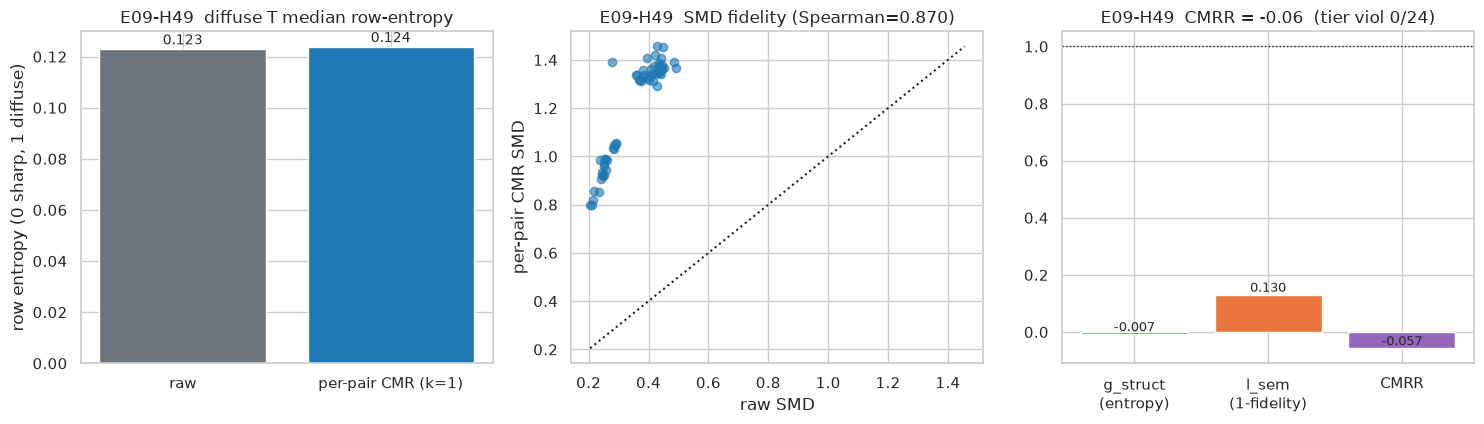

E09-H49: Refuted | CMRR -0.06 | entropy 0.123->0.124 (g_struct -0.007); SMD-fidelity 0.870 (l_sem 0.130); tier viol 0/24; naive margin +0.093->+0.025; CMRR -0.06


In [6]:
H49 = score_axes(perpair_cmr(1))
m49 = cmrr(RAW, H49)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].bar(["raw", "per-pair CMR (k=1)"], [RAW["entropy_med"], H49["entropy_med"]],
          color=[COL["raw"], COL["perpair"]])
ax[0].set(title="E09-H49  diffuse T median row-entropy", ylabel="row entropy (0 sharp, 1 diffuse)")
for xi, v in enumerate([RAW["entropy_med"], H49["entropy_med"]]):
    ax[0].text(xi, v + .002, f"{v:.3f}", ha="center", fontsize=10)
ax[1].scatter(RAW["SMD"], H49["SMD"], alpha=0.6, color=COL["perpair"])
lim = [min(RAW["SMD"].min(), H49["SMD"].min()), max(RAW["SMD"].max(), H49["SMD"].max())]
ax[1].plot(lim, lim, ls=":", color=COL["chance"])
ax[1].set(title=f"E09-H49  SMD fidelity (Spearman={m49['smd_fidelity']:.3f})",
          xlabel="raw SMD", ylabel="per-pair CMR SMD")
bars = ax[2].bar(["g_struct\n(entropy)", "l_sem\n(1-fidelity)", "CMRR"],
                 [m49["g_struct_entropy"], m49["l_sem"], m49["cmrr"]],
                 color=[COL["gain"], COL["cost"], COL["cmrr"]])
ax[2].axhline(1.0, color=COL["chance"], ls=":", lw=1)
ax[2].set(title=f"E09-H49  CMRR = {m49['cmrr']:.2f}  (tier viol {H49['tier_viol']}/{H49['tier_pairs']})")
for b, v in zip(bars, [m49["g_struct_entropy"], m49["l_sem"], m49["cmrr"]]):
    ax[2].text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

sharper = m49["g_struct_entropy"] > 0
tier_ok = H49["tier_viol"] == 0
ships = sharper and tier_ok and m49["cmrr"] > 1
RESULTS["E09-H49"] = {**{k: m49[k] for k in ("g_struct_entropy","g_struct_dr","g_margin","smd_fidelity","l_sem","cmrr")},
                      "entropy_raw": RAW["entropy_med"], "entropy_cmr": H49["entropy_med"],
                      "struct_dr_raw": RAW["struct_dr"], "struct_dr_cmr": H49["struct_dr"],
                      "naive_margin_raw": RAW["naive_margin"], "naive_margin_cmr": H49["naive_margin"],
                      "tier_viol": H49["tier_viol"], "tier_pairs": H49["tier_pairs"]}
VERDICTS["E09-H49"] = {
    "verdict": "Confirmed" if ships else ("Refuted" if not sharper or not tier_ok else "Inconclusive"),
    "applicability": "high" if ships else ("low" if sharper and tier_ok else "none"),
    "cmrr": m49["cmrr"],
    "detail": f"entropy {RAW['entropy_med']:.3f}->{H49['entropy_med']:.3f} "
              f"(g_struct {m49['g_struct_entropy']:+.3f}); SMD-fidelity {m49['smd_fidelity']:.3f} "
              f"(l_sem {m49['l_sem']:.3f}); tier viol {H49['tier_viol']}/{H49['tier_pairs']}; "
              f"naive margin {RAW['naive_margin']:+.3f}->{H49['naive_margin']:+.3f}; CMRR {m49['cmrr']:.2f}"}
logger.info("E09-H49 {} | {}", VERDICTS["E09-H49"]["verdict"], VERDICTS["E09-H49"]["detail"])
print("E09-H49:", VERDICTS["E09-H49"]["verdict"], "| CMRR", f"{m49['cmrr']:.2f}", "|", VERDICTS["E09-H49"]["detail"])

## E09-H50 - selectivity: per-pair vs offline-frozen vs raw

Three arms. **Raw** rejects nothing. **Per-pair** (E09-H49) rejects the test pair's shared
mode - high rejection, low selectivity (it can take the shared topic with it). **Offline-frozen**
fits a top-1 direction once on the source-article background and applies it per pair - it
rejects only the global frequency anisotropy, never the pair's topic (high selectivity, lower
rejection). **Prediction**: offline preserves the semantic shared-content signal better but
sharpens less; per-pair sharpens more but pays semantically; the CMRR picks the winner.

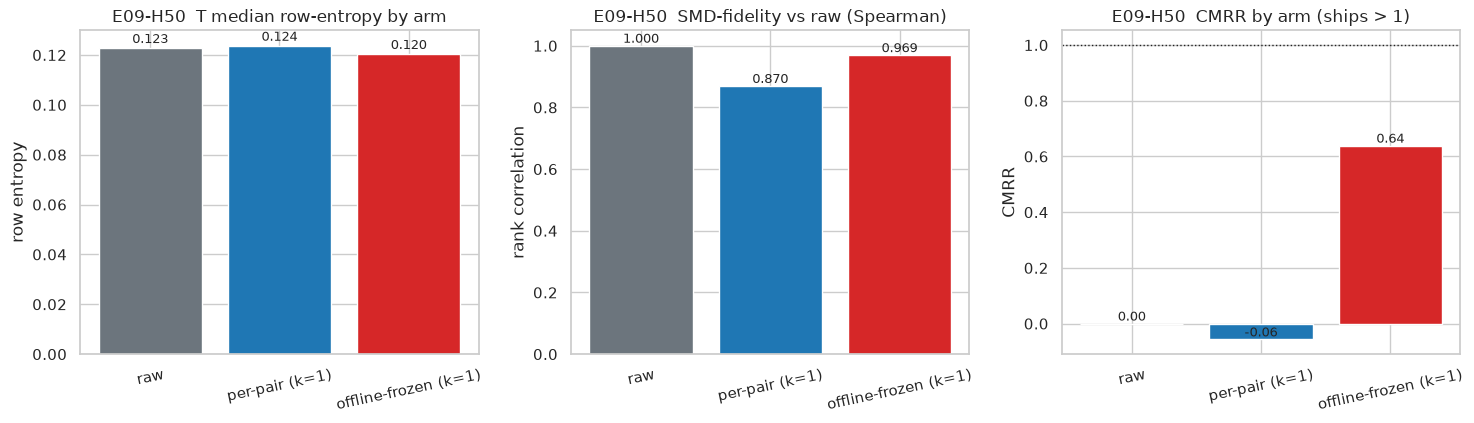

E09-H50: Inconclusive | winner offline-frozen (k=1) | winner=offline-frozen (k=1) (CMRR 0.64); per-pair CMRR -0.06 fidelity 0.870; offline CMRR 0.64 fidelity 0.969


In [7]:
arms = {"raw": raw_cmr, "per-pair (k=1)": perpair_cmr(1), "offline-frozen (k=1)": offline_cmr(1)}
scored = {name: score_axes(fn) for name, fn in arms.items()}
mets = {name: (cmrr(RAW, s) if name != "raw" else {"g_struct_entropy": 0.0, "g_struct_dr": 0.0,
        "g_margin": 0.0, "smd_fidelity": 1.0, "l_sem": 0.0, "cmrr": 0.0, "l_sem_floored": True})
        for name, s in scored.items()}
names = list(arms)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
cols = [COL["raw"], COL["perpair"], COL["offline"]]
ax[0].bar(names, [scored[n]["entropy_med"] for n in names], color=cols)
ax[0].set(title="E09-H50  T median row-entropy by arm", ylabel="row entropy")
for xi, n in enumerate(names):
    ax[0].text(xi, scored[n]["entropy_med"] + .002, f"{scored[n]['entropy_med']:.3f}", ha="center", fontsize=9)
ax[0].tick_params(axis="x", labelrotation=12)
ax[1].bar(names, [mets[n]["smd_fidelity"] for n in names], color=cols)
ax[1].set(title="E09-H50  SMD-fidelity vs raw (Spearman)", ylabel="rank correlation", ylim=(0, 1.05))
for xi, n in enumerate(names):
    ax[1].text(xi, mets[n]["smd_fidelity"], f"{mets[n]['smd_fidelity']:.3f}", ha="center", va="bottom", fontsize=9)
ax[1].tick_params(axis="x", labelrotation=12)
ax[2].bar(names, [mets[n]["cmrr"] for n in names], color=cols)
ax[2].axhline(1.0, color=COL["chance"], ls=":", lw=1)
ax[2].set(title="E09-H50  CMRR by arm (ships > 1)", ylabel="CMRR")
for xi, n in enumerate(names):
    ax[2].text(xi, mets[n]["cmrr"], f"{mets[n]['cmrr']:.2f}", ha="center", va="bottom", fontsize=9)
ax[2].tick_params(axis="x", labelrotation=12)
plt.tight_layout(); plt.show()

cmr_arms = {n: mets[n]["cmrr"] for n in names if n != "raw"}
winner = max(cmr_arms, key=cmr_arms.get)
win_ships = mets[winner]["cmrr"] > 1 and scored[winner]["tier_viol"] == 0 and mets[winner]["g_struct_entropy"] > 0
RESULTS["E09-H50"] = {n: {"entropy_med": scored[n]["entropy_med"], "smd_fidelity": mets[n]["smd_fidelity"],
                         "g_struct_entropy": mets[n]["g_struct_entropy"], "cmrr": mets[n]["cmrr"],
                         "tier_viol": scored[n]["tier_viol"]} for n in names}
RESULTS["E09-H50"]["winner"] = winner
VERDICTS["E09-H50"] = {
    "verdict": "Confirmed" if win_ships else "Inconclusive",
    "applicability": "high" if win_ships else ("low" if mets[winner]["cmrr"] > 0 else "none"),
    "cmrr": mets[winner]["cmrr"],
    "detail": f"winner={winner} (CMRR {mets[winner]['cmrr']:.2f}); per-pair CMRR {cmr_arms.get('per-pair (k=1)',0):.2f} "
              f"fidelity {mets['per-pair (k=1)']['smd_fidelity']:.3f}; offline CMRR "
              f"{cmr_arms.get('offline-frozen (k=1)',0):.2f} fidelity {mets['offline-frozen (k=1)']['smd_fidelity']:.3f}"}
logger.info("E09-H50 {} | {}", VERDICTS["E09-H50"]["verdict"], VERDICTS["E09-H50"]["detail"])
print("E09-H50:", VERDICTS["E09-H50"]["verdict"], "| winner", winner, "|", VERDICTS["E09-H50"]["detail"])

## E09-H51 - rejection depth: top-D sweep

Sweep D in {0,1,2,3} on the both-document pool (D=0 is raw). For each D score both axes and
the bootstrap stability of the removed top-D direction (mean subspace alignment across
resampled pooled-statement draws). **Prediction**: CMRR peaks at a shallow D (1, possibly 2);
D >= 3 over-rejects and degrades the semantic axis, and the removed direction's bootstrap
stability falls off past D=1-2.

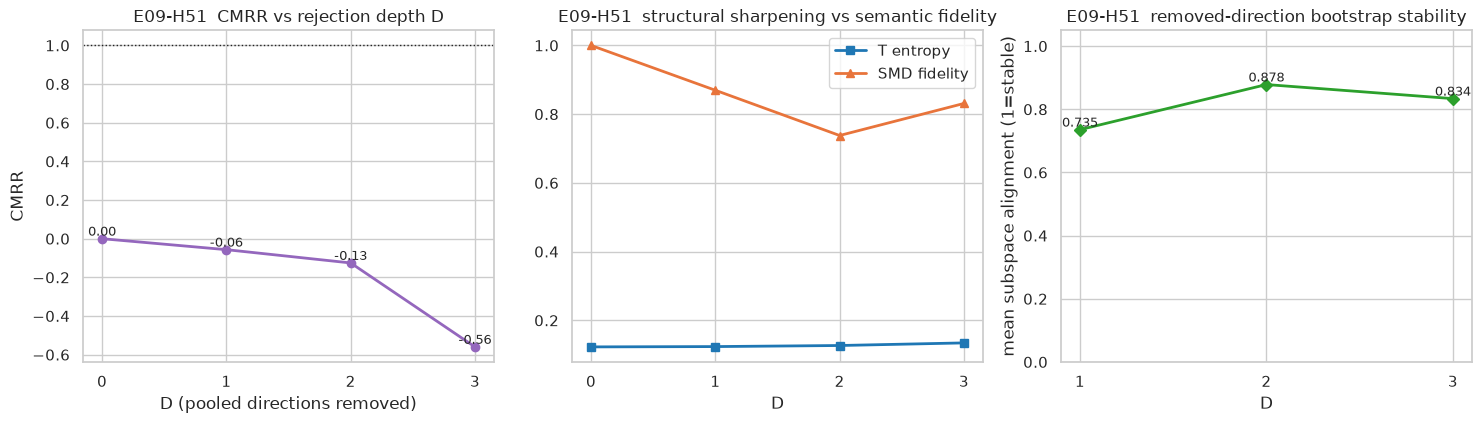

E09-H51: Inconclusive | best D 0 | best D=0 (CMRR 0.00); CMRR by D [0.0, -0.06, -0.13, -0.56]; stability {D1:0.74, D2:0.88, D3:0.83}; unstable (<0.9) at D=[1, 2, 3]


In [8]:
depth_scores, depth_met, depth_stab = {}, {}, {}
for D in DEPTHS:
    s = score_axes(raw_cmr if D == 0 else perpair_cmr(D))
    depth_scores[D] = s
    depth_met[D] = cmrr(RAW, s) if D > 0 else {"g_struct_entropy": 0.0, "g_struct_dr": 0.0,
        "g_margin": 0.0, "smd_fidelity": 1.0, "l_sem": 0.0, "cmrr": 0.0, "l_sem_floored": True}
    if D > 0:
        depth_stab[D] = float(np.mean([direction_stability(EMB[a], EMB[b], D) for a, b in DIFFUSE]))

cmrr_by_d = [depth_met[D]["cmrr"] for D in DEPTHS]
fid_by_d = [depth_met[D]["smd_fidelity"] for D in DEPTHS]
ent_by_d = [depth_scores[D]["entropy_med"] for D in DEPTHS]
stab_d = [depth_stab.get(D, np.nan) for D in DEPTHS]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].plot(DEPTHS, cmrr_by_d, "o-", color=COL["cmrr"], lw=2)
ax[0].axhline(1.0, color=COL["chance"], ls=":", lw=1)
ax[0].set(title="E09-H51  CMRR vs rejection depth D", xlabel="D (pooled directions removed)", ylabel="CMRR", xticks=DEPTHS)
for d, v in zip(DEPTHS, cmrr_by_d):
    ax[0].text(d, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax[1].plot(DEPTHS, ent_by_d, "s-", color=COL["perpair"], lw=2, label="T entropy")
ax[1].plot(DEPTHS, fid_by_d, "^-", color=COL["cost"], lw=2, label="SMD fidelity")
ax[1].set(title="E09-H51  structural sharpening vs semantic fidelity", xlabel="D", xticks=DEPTHS)
ax[1].legend()
ax[2].plot(DEPTHS[1:], stab_d[1:], "D-", color=COL["gain"], lw=2)
ax[2].set(title="E09-H51  removed-direction bootstrap stability", xlabel="D",
          ylabel="mean subspace alignment (1=stable)", xticks=DEPTHS[1:], ylim=(0, 1.05))
for d, v in zip(DEPTHS[1:], stab_d[1:]):
    ax[2].text(d, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

best_d = int(DEPTHS[int(np.argmax(cmrr_by_d))])
STAB_BAR = 0.9
unstable_d = [D for D in DEPTHS if D > 0 and depth_stab[D] < STAB_BAR]
RESULTS["E09-H51"] = {"depths": DEPTHS, "cmrr_by_d": cmrr_by_d, "fidelity_by_d": fid_by_d,
                      "entropy_by_d": ent_by_d, "stability_by_d": {str(D): depth_stab.get(D) for D in DEPTHS if D > 0},
                      "best_d": best_d, "stability_bar": STAB_BAR, "unstable_depths": unstable_d}
VERDICTS["E09-H51"] = {
    "verdict": "Confirmed" if (best_d in (1, 2) and max(cmrr_by_d) > 1) else "Inconclusive",
    "applicability": "high" if max(cmrr_by_d) > 1 else ("low" if max(cmrr_by_d) > 0 else "none"),
    "cmrr": float(max(cmrr_by_d)),
    "detail": f"best D={best_d} (CMRR {max(cmrr_by_d):.2f}); CMRR by D {[round(v,2) for v in cmrr_by_d]}; "
              f"stability {{{', '.join(f'D{D}:{depth_stab[D]:.2f}' for D in DEPTHS if D>0)}}}; "
              f"unstable (<{STAB_BAR}) at D={unstable_d or 'none'}"}
logger.info("E09-H51 {} | {}", VERDICTS["E09-H51"]["verdict"], VERDICTS["E09-H51"]["detail"])
print("E09-H51:", VERDICTS["E09-H51"]["verdict"], "| best D", best_d, "|", VERDICTS["E09-H51"]["detail"])

## E09-H52 - segmentation granularity: sample count vs unit noise

Finer segmentation yields more statements (more PCA samples, a better pooled common-mode
estimate) but noisier per-unit embeddings (less context each), so there should be a sweet
spot. The fixture `Segmenter` (SAT) exposes only `split(text)` with no public threshold knob,
so granularity is varied by **re-deriving units from the fixture statements** and re-embedding:
**coarse** merges adjacent statement pairs (fewer, larger units), **default** is the SAT
fixture segmentation, **fine** clause-splits each statement on `, ; : -` boundaries with a
4-word floor (more, smaller units). The E09-H49 per-pair CMR (k=1) is rerun at each
granularity; PCA top-1 bootstrap stability and both axes are tracked.

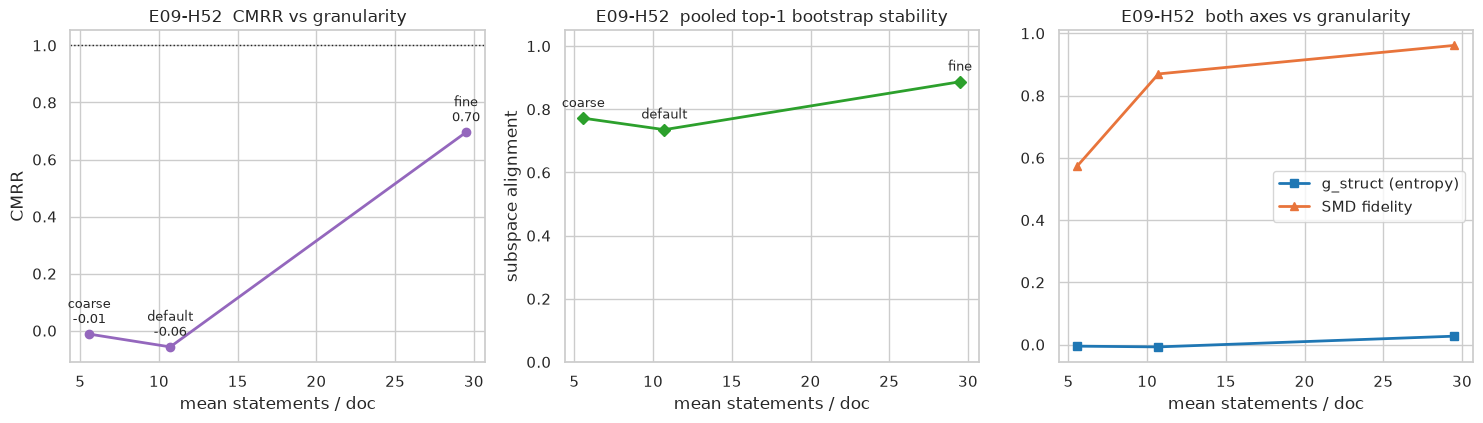

E09-H52: Refuted | best fine | best=fine CMRR 0.70 (n~30); CMRR coarse -0.01 / default -0.06 / fine 0.70; stability {coarse:0.77, default:0.74, fine:0.89}; fallback=clause-split (no SAT threshold knob)


In [9]:
def clause_split(stmt, min_words=4):
    parts = re.split(r"(?<=[,;:])\s+|\s+[-\u2014]\s+", stmt)
    out, buf = [], ""
    for p in parts:
        buf = (buf + " " + p).strip() if buf else p.strip()
        if len(buf.split()) >= min_words:
            out.append(buf); buf = ""
    if buf:
        if out: out[-1] = (out[-1] + " " + buf).strip()
        else: out.append(buf)
    return out

def merge_pairs(stmts):
    return [" ".join(stmts[i:i + 2]) for i in range(0, len(stmts), 2)]

DOC_LABELS = sorted({a for a, _ in DIFFUSE} | {b for _, b in DIFFUSE} | {p["a"] for p in TIER} | {p["b"] for p in TIER})
def resegment(level):
    out = {}
    for lbl in DOC_LABELS:
        st = DOCSTORE[lbl]["statements"]
        if level == "coarse": st = merge_pairs(st)
        elif level == "fine": st = [u for s in st for u in clause_split(s)]
        out[lbl] = st
    return out

LEVELS = ["coarse", "default", "fine"]
gran_emb, gran_n = {}, {}
for lv in LEVELS:
    seg = {lbl: DOCSTORE[lbl]["statements"] for lbl in DOC_LABELS} if lv == "default" else resegment(lv)
    gran_emb[lv] = {lbl: ENC.encode(seg[lbl]) for lbl in DOC_LABELS}
    gran_n[lv] = float(np.mean([len(seg[lbl]) for lbl in DOC_LABELS]))

gran_cmrr, gran_fid, gran_gstruct, gran_stab, gran_viol = {}, {}, {}, {}, {}
for lv in LEVELS:
    emap = gran_emb[lv]
    raw_lv = score_axes(raw_cmr, embmap=emap)
    cmr_lv = score_axes(perpair_cmr(1), embmap=emap)
    m = cmrr(raw_lv, cmr_lv)
    gran_cmrr[lv], gran_fid[lv], gran_gstruct[lv] = m["cmrr"], m["smd_fidelity"], m["g_struct_entropy"]
    gran_viol[lv] = cmr_lv["tier_viol"]
    gran_stab[lv] = float(np.mean([direction_stability(emap[a], emap[b], 1) for a, b in DIFFUSE]))

xs = [gran_n[lv] for lv in LEVELS]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].plot(xs, [gran_cmrr[lv] for lv in LEVELS], "o-", color=COL["cmrr"], lw=2)
ax[0].axhline(1.0, color=COL["chance"], ls=":", lw=1)
ax[0].set(title="E09-H52  CMRR vs granularity", xlabel="mean statements / doc", ylabel="CMRR")
for lv, x in zip(LEVELS, xs):
    ax[0].annotate(f"{lv}\n{gran_cmrr[lv]:.2f}", (x, gran_cmrr[lv]), textcoords="offset points",
                   xytext=(0, 8), ha="center", fontsize=9)
ax[1].plot(xs, [gran_stab[lv] for lv in LEVELS], "D-", color=COL["gain"], lw=2)
ax[1].set(title="E09-H52  pooled top-1 bootstrap stability", xlabel="mean statements / doc",
          ylabel="subspace alignment", ylim=(0, 1.05))
for lv, x in zip(LEVELS, xs):
    ax[1].annotate(f"{lv}", (x, gran_stab[lv]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax[2].plot(xs, [gran_gstruct[lv] for lv in LEVELS], "s-", color=COL["perpair"], lw=2, label="g_struct (entropy)")
ax[2].plot(xs, [gran_fid[lv] for lv in LEVELS], "^-", color=COL["cost"], lw=2, label="SMD fidelity")
ax[2].set(title="E09-H52  both axes vs granularity", xlabel="mean statements / doc"); ax[2].legend()
plt.tight_layout(); plt.show()

coarse_default_cmrr = gran_cmrr["default"]
best_lv = max(LEVELS, key=lambda lv: gran_cmrr[lv])
clears = gran_cmrr[best_lv] > 1 and gran_viol[best_lv] == 0 and gran_gstruct[best_lv] > 0
beats_default = gran_cmrr[best_lv] > coarse_default_cmrr and best_lv != "default"
RESULTS["E09-H52"] = {"levels": LEVELS, "mean_n": {lv: gran_n[lv] for lv in LEVELS},
                      "cmrr": gran_cmrr, "smd_fidelity": gran_fid, "g_struct_entropy": gran_gstruct,
                      "stability": gran_stab, "tier_viol": gran_viol, "best_level": best_lv}
VERDICTS["E09-H52"] = {
    "verdict": "Confirmed" if (clears and beats_default) else ("Inconclusive" if clears else "Refuted"),
    "applicability": "medium" if clears else "none",
    "cmrr": gran_cmrr[best_lv],
    "detail": f"best={best_lv} CMRR {gran_cmrr[best_lv]:.2f} (n~{gran_n[best_lv]:.0f}); "
              f"CMRR coarse {gran_cmrr['coarse']:.2f} / default {gran_cmrr['default']:.2f} / fine {gran_cmrr['fine']:.2f}; "
              f"stability {{{', '.join(f'{lv}:{gran_stab[lv]:.2f}' for lv in LEVELS)}}}; "
              f"fallback=clause-split (no SAT threshold knob)"}
logger.info("E09-H52 {} | {}", VERDICTS["E09-H52"]["verdict"], VERDICTS["E09-H52"]["detail"])
print("E09-H52:", VERDICTS["E09-H52"]["verdict"], "| best", best_lv, "|", VERDICTS["E09-H52"]["detail"])

## E09-H53 - the single (basic SMD) under both-document CMR

The shipped single-pair content distance runs raw (`anisotropy=False`). Both-document CMR is
the natural way to recover anisotropy removal without a corpus. **Prediction**: on diffuse
pairs it widens the SMD dynamic range but may compress the gold/adversarial margin if it
removes shared topic - the content SOTA "DR up, d' down" tradeoff, now estimated per-pair from
both documents. **Bar**: SMD tier ordering preserved (0 violations) with dynamic range up;
report the d' tradeoff.

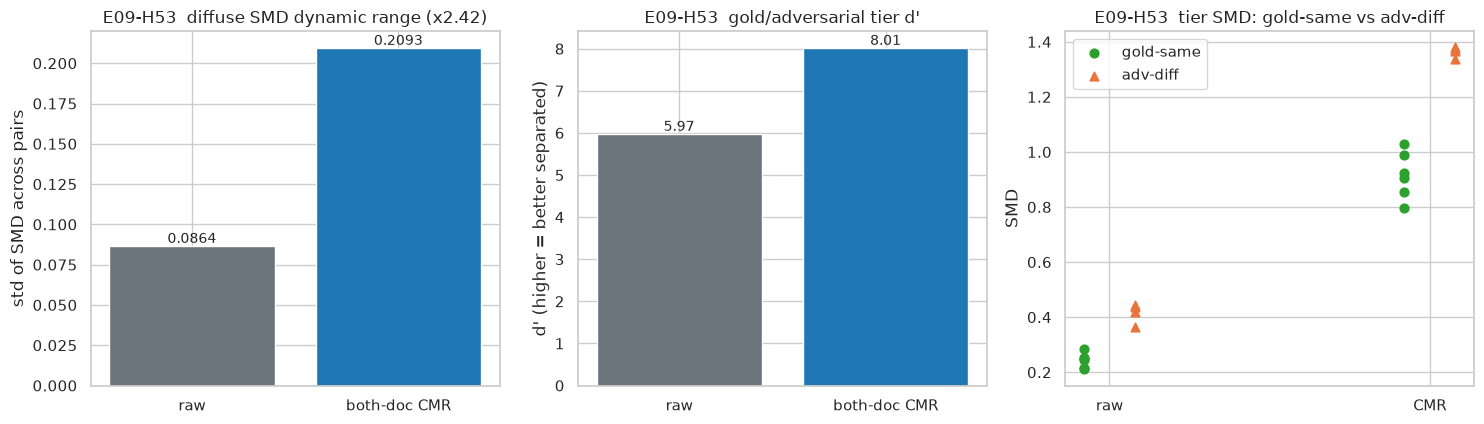

E09-H53: Confirmed | DR x 2.42 | SMD DR 0.0864->0.2093 (x2.42); tier d' 5.97->8.01 (d-prime up); tier viol 0->0/24


In [10]:
raw_smd = RAW["SMD"]
cmr_smd = H49["SMD"]   # per-pair k=1 CMR SMD on the diffuse pairs (already computed)
dr_raw, dr_cmr = float(np.std(raw_smd)), float(np.std(cmr_smd))
dr_ratio = dr_cmr / max(dr_raw, 1e-9)
dprime_raw, dprime_cmr = RAW["tier_dprime"], H49["tier_dprime"]
viol_raw, viol_cmr = RAW["tier_viol"], H49["tier_viol"]

# tier SMD distributions raw vs CMR for the strip panel
def tier_smds(transform):
    same = [smd(*transform(EMB[p["a"]], EMB[p["b"]])) for p in TIER if p["content"] == "same"]
    diff = [smd(*transform(EMB[p["a"]], EMB[p["b"]])) for p in TIER if p["content"] == "diff"]
    return np.array(same), np.array(diff)
same_raw, diff_raw = tier_smds(raw_cmr)
same_cmr, diff_cmr = tier_smds(perpair_cmr(1))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].bar(["raw", "both-doc CMR"], [dr_raw, dr_cmr], color=[COL["raw"], COL["perpair"]])
ax[0].set(title=f"E09-H53  diffuse SMD dynamic range (x{dr_ratio:.2f})", ylabel="std of SMD across pairs")
for xi, v in enumerate([dr_raw, dr_cmr]):
    ax[0].text(xi, v, f"{v:.4f}", ha="center", va="bottom", fontsize=10)
ax[1].bar(["raw", "both-doc CMR"], [dprime_raw, dprime_cmr], color=[COL["raw"], COL["perpair"]])
ax[1].set(title="E09-H53  gold/adversarial tier d'", ylabel="d' (higher = better separated)")
for xi, v in enumerate([dprime_raw, dprime_cmr]):
    ax[1].text(xi, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
for xi, (s, d, tag) in enumerate([(same_raw, diff_raw, "raw"), (same_cmr, diff_cmr, "CMR")]):
    ax[2].scatter([xi - 0.08] * len(s), s, color=COL["gain"], label="gold-same" if xi == 0 else None, s=40)
    ax[2].scatter([xi + 0.08] * len(d), d, color=COL["cost"], label="adv-diff" if xi == 0 else None, s=40, marker="^")
ax[2].set(title="E09-H53  tier SMD: gold-same vs adv-diff", xticks=[0, 1], xticklabels=["raw", "CMR"], ylabel="SMD")
ax[2].legend()
plt.tight_layout(); plt.show()

dr_up = dr_ratio > 1.0
tier_ok53 = viol_cmr == 0
RESULTS["E09-H53"] = {"dr_raw": dr_raw, "dr_cmr": dr_cmr, "dr_ratio": dr_ratio,
                      "tier_dprime_raw": dprime_raw, "tier_dprime_cmr": dprime_cmr,
                      "tier_viol_raw": viol_raw, "tier_viol_cmr": viol_cmr,
                      "tier_same_mean_raw": float(same_raw.mean()), "tier_diff_mean_raw": float(diff_raw.mean()),
                      "tier_same_mean_cmr": float(same_cmr.mean()), "tier_diff_mean_cmr": float(diff_cmr.mean())}
VERDICTS["E09-H53"] = {
    "verdict": "Confirmed" if (dr_up and tier_ok53) else ("Refuted" if not tier_ok53 else "Inconclusive"),
    "applicability": "medium" if (dr_up and tier_ok53) else ("low" if tier_ok53 else "none"),
    "cmrr": dr_ratio,
    "detail": f"SMD DR {dr_raw:.4f}->{dr_cmr:.4f} (x{dr_ratio:.2f}); tier d' {dprime_raw:.2f}->{dprime_cmr:.2f} "
              f"({'d-prime up' if dprime_cmr>=dprime_raw else 'd-prime down (topic-removal cost)'}); "
              f"tier viol {viol_raw}->{viol_cmr}/{RAW['tier_pairs']}"}
logger.info("E09-H53 {} | {}", VERDICTS["E09-H53"]["verdict"], VERDICTS["E09-H53"]["detail"])
print("E09-H53:", VERDICTS["E09-H53"]["verdict"], "| DR x", f"{dr_ratio:.2f}", "|", VERDICTS["E09-H53"]["detail"])

## Verdicts and conclusions

Per-hypothesis verdict (Confirmed / Refuted / Inconclusive + applicability) with the measured
CMRR, in the E08 style, plus a CMRR-across-hypotheses summary figure. Written to
`reports/E09-anisotropy-cmr-metrics.json`.

                                E09 verdicts - anisotropy as common-mode rejection                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ hypothesis                             ┃ verdict      ┃ applicability ┃ CMRR / headline                         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E09-H49                                │ Refuted      │ none          │ -0.06                                   │
│ per-pair both-document top-1 CMR       │              │               │ entropy 0.123->0.124 (g_struct -0.007); │
│                                        │              │               │ SMD-fidelity 0.870 (l_sem 0.130); tier  │
│                                        │              │               │ viol 0/24; naive margin +0.093->+0.025; │
│                                        │              │               │ CMRR -0.06                              │
│ E09-H50                                │ Inconclusive │ low           │ 0.64                                    │
│ selectivity: per-pair vs               │              │               │ winner=offline-frozen (k=1) (CMRR       │
│ offline-frozen vs raw                  │              │               │ 0.64); per-pair CMRR -0.06 fidelity     │
│                                        │              │               │ 0.870; offline CMRR 0.64 fidelity 0.969 │
│ E09-H51                                │ Inconclusive │ none          │ 0.00                                    │
│ rejection depth top-D sweep            │              │               │ best D=0 (CMRR 0.00); CMRR by D [0.0,   │
│                                        │              │               │ -0.06, -0.13, -0.56]; stability         │
│                                        │              │               │ {D1:0.74, D2:0.88, D3:0.83}; unstable   │
│                                        │              │               │ (<0.9) at D=[1, 2, 3]                   │
│ E09-H52                                │ Refuted      │ none          │ 0.70                                    │
│ segmentation granularity               │              │               │ best=fine CMRR 0.70 (n~30); CMRR coarse │
│                                        │              │               │ -0.01 / default -0.06 / fine 0.70;      │
│                                        │              │               │ stability {coarse:0.77, default:0.74,   │
│                                        │              │               │ fine:0.89}; fallback=clause-split (no   │
│                                        │              │               │ SAT threshold knob)                     │
│ E09-H53                                │ Confirmed    │ medium        │ 2.42                                    │
│ single basic SMD under both-document   │              │               │ SMD DR 0.0864->0.2093 (x2.42); tier d'  │
│ CMR                                    │              │               │ 5.97->8.01 (d-prime up); tier viol      │
│                                        │              │               │ 0->0/24                                 │
└────────────────────────────────────────┴──────────────┴───────────────┴─────────────────────────────────────────┘

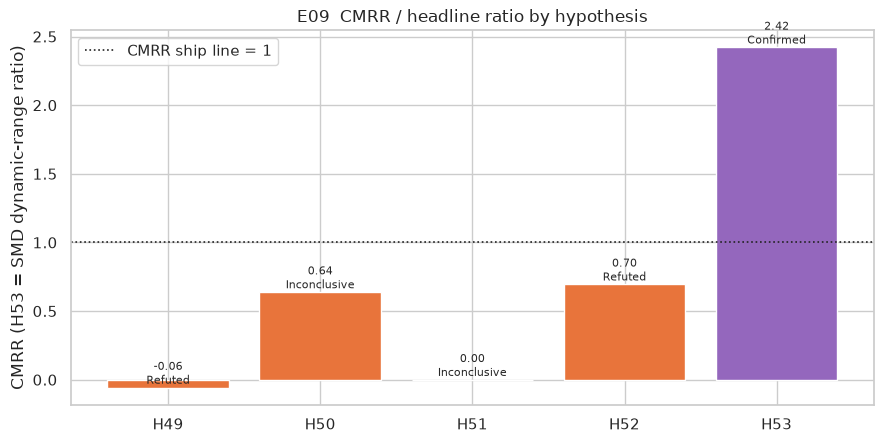

wrote /home/lab/workspace/learning/projects/docdistance/reports/E09-anisotropy-cmr-metrics.json


In [11]:
head = {"E09-H49": "per-pair both-document top-1 CMR",
        "E09-H50": "selectivity: per-pair vs offline-frozen vs raw",
        "E09-H51": "rejection depth top-D sweep",
        "E09-H52": "segmentation granularity",
        "E09-H53": "single basic SMD under both-document CMR"}
ORDER = ["E09-H49", "E09-H50", "E09-H51", "E09-H52", "E09-H53"]

t = Table(title="E09 verdicts - anisotropy as common-mode rejection", title_style="bold green")
for c in ("hypothesis", "verdict", "applicability", "CMRR / headline"):
    t.add_column(c, overflow="fold", style="cyan" if c == "hypothesis" else None)
for h in ORDER:
    t.add_row(f"{h}\n{head[h]}", VERDICTS[h]["verdict"], VERDICTS[h]["applicability"],
              f"{VERDICTS[h]['cmrr']:.2f}\n{VERDICTS[h]['detail']}")
console.print(t)

fig, ax = plt.subplots(figsize=(9, 4.6))
vals = [VERDICTS[h]["cmrr"] for h in ORDER]
barcol = [COL["cmrr"] if VERDICTS[h]["verdict"] == "Confirmed" else COL["cost"] for h in ORDER]
bars = ax.bar([h.replace("E09-", "") for h in ORDER], vals, color=barcol)
ax.axhline(1.0, color=COL["chance"], ls=":", lw=1.2, label="CMRR ship line = 1")
ax.set(title="E09  CMRR / headline ratio by hypothesis", ylabel="CMRR (H53 = SMD dynamic-range ratio)")
for b, h in zip(bars, ORDER):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{VERDICTS[h]['cmrr']:.2f}\n{VERDICTS[h]['verdict']}",
            ha="center", va="bottom", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

payload = {"results": RESULTS, "verdicts": VERDICTS,
           "config": {"diffuse_pairs": len(DIFFUSE), "tier_pairs": len(TIER), "lam_head": LAM_HEAD,
                      "depths": DEPTHS, "eps_cmrr": EPS_CMRR, "boot_reps": BOOT_REPS,
                      "granularity_levels": ["coarse", "default", "fine"], "device": DEVICE,
                      "cmrr_def": "structural differential gain (relative T-entropy reduction) / semantic common-content loss (1 - SMD-fidelity Spearman); floored at EPS_CMRR",
                      "regime": "diffuse cross-summary pairs (independent summaries of one article); tier-contrast gold/adversarial guard"}}
REPORT.write_text(json.dumps(payload, indent=2, default=float))
logger.info("wrote {}", REPORT)
print("wrote", REPORT)

## Conclusions

The narrative verdict is filled from the executed cells above - whether both-document CMR
sharpens the diffuse `T` (unlike the already-sharp E08-H47 regime), whether it preserves or
hurts the semantic ranking (the topic-removal risk), the per-pair vs offline-frozen winner,
the best rejection depth D, and whether finer segmentation helped. The pre-registered CMRR > 1
ship line is the headline; any divergence from the registered predictions is the finding. See
the verdict table and `reports/E09-anisotropy-cmr-metrics.json` for the measured numbers.